# RQ1 Analysis Plan
**Plan file:** `02_RQ1_plan.md`  
**Plan code:** `rq1`  
**Dataset:** `data/3_processed_data/master_features/panel_dataset_2020_2023.parquet`  
**Date:** 2026-05-25

> This analysis investigates whether AI preparedness (AI Readiness Index) has a statistically significant influence on sustainability outcomes (SDG Index Score) across 26 countries from 2020 to 2023, using panel regression methods including Pooled OLS, Fixed Effects, and Random Effects models.


In [1]:
import os, pathlib

# ── Ensure CWD is project root (where data/ lives) ───────────────────────────
_cwd = pathlib.Path(os.getcwd())
# Walk up until we find the data/ directory (project root)
_check = _cwd
for _ in range(5):
    if (_check / "data").is_dir():
        os.chdir(str(_check))
        break
    _check = _check.parent
print(f"Working directory: {os.getcwd()}")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from linearmodels.panel import PanelOLS, RandomEffects
    from linearmodels.panel.results import compare
    HAS_LINEARMODELS = True
    print("✅ linearmodels available")
except ImportError:
    HAS_LINEARMODELS = False
    print("⚠️  linearmodels not installed — panel models will use statsmodels LSDV workaround")

# ── McKinsey dark-navy style constants ────────────────────────────────────────
BG_DARK        = "#0A1628"
GRID_COLOR     = "#1E3A5F"
TEXT_WHITE     = "#FFFFFF"
TEXT_DARK      = "#0A1628"
C1             = "#4FC3F7"   # sky blue  — Developed
C2             = "#4DB6AC"   # teal      — Developing
C3             = "#1A73E8"   # blue      — Lower Governance
C4             = "#FFD600"   # gold      — accent
C5             = "#FF7043"   # orange    — 5th series

GROUP_COLORS = {
    "Developed":        C1,
    "Developing":       C2,
    "Lower Governance": C3,
}

MCKINSEY_RC = {
    "figure.facecolor": BG_DARK, "figure.figsize": (14, 7), "figure.dpi": 150,
    "axes.facecolor": BG_DARK, "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_WHITE, "axes.titlecolor": TEXT_WHITE,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 16,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.spines.bottom": False,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID_COLOR, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "lines.linewidth": 2.5,
    "xtick.color": TEXT_WHITE, "ytick.color": TEXT_WHITE,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.facecolor": BG_DARK, "legend.framealpha": 0.0,
    "legend.labelcolor": TEXT_WHITE, "legend.fontsize": 9,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
    "text.color": TEXT_WHITE,
    "savefig.facecolor": BG_DARK, "savefig.bbox": "tight", "savefig.dpi": 150,
}
plt.rcParams.update(MCKINSEY_RC)

os.makedirs("outputs", exist_ok=True)
print("✅ Setup complete — McKinsey theme loaded")

Working directory: /Users/mohamedinas/Desktop/SE_projects/9_fathima_stat_support/version_v1/8_interview_prep


✅ linearmodels available
✅ Setup complete — McKinsey theme loaded


## Data Loading
Loading the panel dataset and verifying structure.


In [2]:
DATA_PATH = "data/3_processed_data/master_features/panel_dataset_2020_2023.parquet"
df = pd.read_parquet(DATA_PATH)

# Cast to float64 for numeric stability
for col in ["ai_readiness_score", "sdg_index_score", "wgi_composite"]:
    df[col] = df[col].astype(float)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Countries: {df['country'].nunique()} | Years: {sorted(df['year'].unique())} | Groups: {df['country_group'].unique().tolist()}")
print("\nColumn dtypes:")
print(df.dtypes.to_string())
df.head(8)


Dataset shape: 104 rows × 7 columns
Countries: 26 | Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] | Groups: ['Developed', 'Developing', 'Lower Governance']

Column dtypes:
iso_code                  str
country                   str
country_group             str
year                    int64
ai_readiness_score    float64
sdg_index_score       float64
wgi_composite         float64


,iso_code,country,country_group,year,ai_readiness_score,sdg_index_score,wgi_composite
0,CAN,Canada,Developed,2020,73.158,79.370003,1.504060
1,CAN,Canada,Developed,2021,77.730,79.040001,1.452090
2,CAN,Canada,Developed,2022,77.390,79.209999,1.430138
3,CAN,Canada,Developed,2023,77.070,79.279999,1.419729
4,DNK,Denmark,Developed,2020,75.618,85.010002,1.825962
5,DNK,Denmark,Developed,2021,76.960,84.910004,1.874868
6,DNK,Denmark,Developed,2022,74.790,85.029999,1.863013
7,DNK,Denmark,Developed,2023,73.910,85.250000,1.849802


## Step 1 — Descriptive Statistics

Computing mean, median, standard deviation, min, max for `ai_readiness_score` and `sdg_index_score` — overall, by country group, and by year.


In [3]:
prefix = "rq1"
desc_cols = ["ai_readiness_score", "sdg_index_score"]

# ── Overall descriptive statistics ────────────────────────────────────────────
overall = df[desc_cols].describe().T.round(3)
overall.columns = ["count", "mean", "std", "min", "25%", "median", "75%", "max"]
overall["median"] = df[desc_cols].median().round(3)
print("=== Overall Descriptive Statistics ===")
display(overall)

# ── By country group ──────────────────────────────────────────────────────────
by_group = df.groupby("country_group")[desc_cols].describe().round(3)
print("\n=== By Country Group ===")
display(by_group)

# ── Year-wise means ───────────────────────────────────────────────────────────
by_year = df.groupby("year")[desc_cols].mean().round(3)
print("\n=== Year-wise Means ===")
display(by_year)

# ── Save ─────────────────────────────────────────────────────────────────────
overall.to_csv(f"outputs/{prefix}_descriptive_stats.csv")
print(f"\n✅ Saved: outputs/{prefix}_descriptive_stats.csv")


=== Overall Descriptive Statistics ===


,count,mean,std,min,25%,median,75%,max
ai_readiness_score,104.0,59.747,17.298,25.30,43.65,62.520,75.252,88.16
sdg_index_score,104.0,71.538,9.511,53.11,63.97,71.155,79.808,87.10



=== By Country Group ===


ai_readiness_score                                        \
                              count    mean    std    min     25%     50%   
country_group                                                               
Developed                      40.0  77.443  3.984  72.55  74.710  77.015   
Developing                     40.0  55.816  9.663  36.23  48.219  55.232   
Lower Governance               24.0  36.804  5.825  25.30  32.900  37.530   

                                sdg_index_score                                \
                     75%    max           count    mean    std    min     25%   
country_group                                                                   
Developed         78.822  88.16            40.0  80.745  5.169  68.80  79.262   
Developing        63.188  74.42            40.0  70.032  3.442  63.50  68.055   
Lower Governance  40.255  46.04            24.0  58.704  4.052  53.11  54.343   

                                         
                     50%     75%    max  
country_group                            
Developed         81.275  85.015  87.10  
Developing        69.670  73.208  75.00  
Lower Governance  58.840  62.867  63.68


=== Year-wise Means ===


,ai_readiness_score,sdg_index_score
year,,
2020,57.293,71.251
2021,60.306,71.369
2022,60.516,71.663
2023,60.872,71.869



✅ Saved: outputs/rq1_descriptive_stats.csv


## Step 2 — Visual Exploration

1. **Scatter plot**: AI Readiness Score (x) vs SDG Index Score (y), colour-coded by country group with OLS trend line  
2. **Line plots**: AI Readiness and SDG Index trends over 2020–2023 (side-by-side, by country group)  
3. **Box plots**: Distribution of both scores by country group (side-by-side)


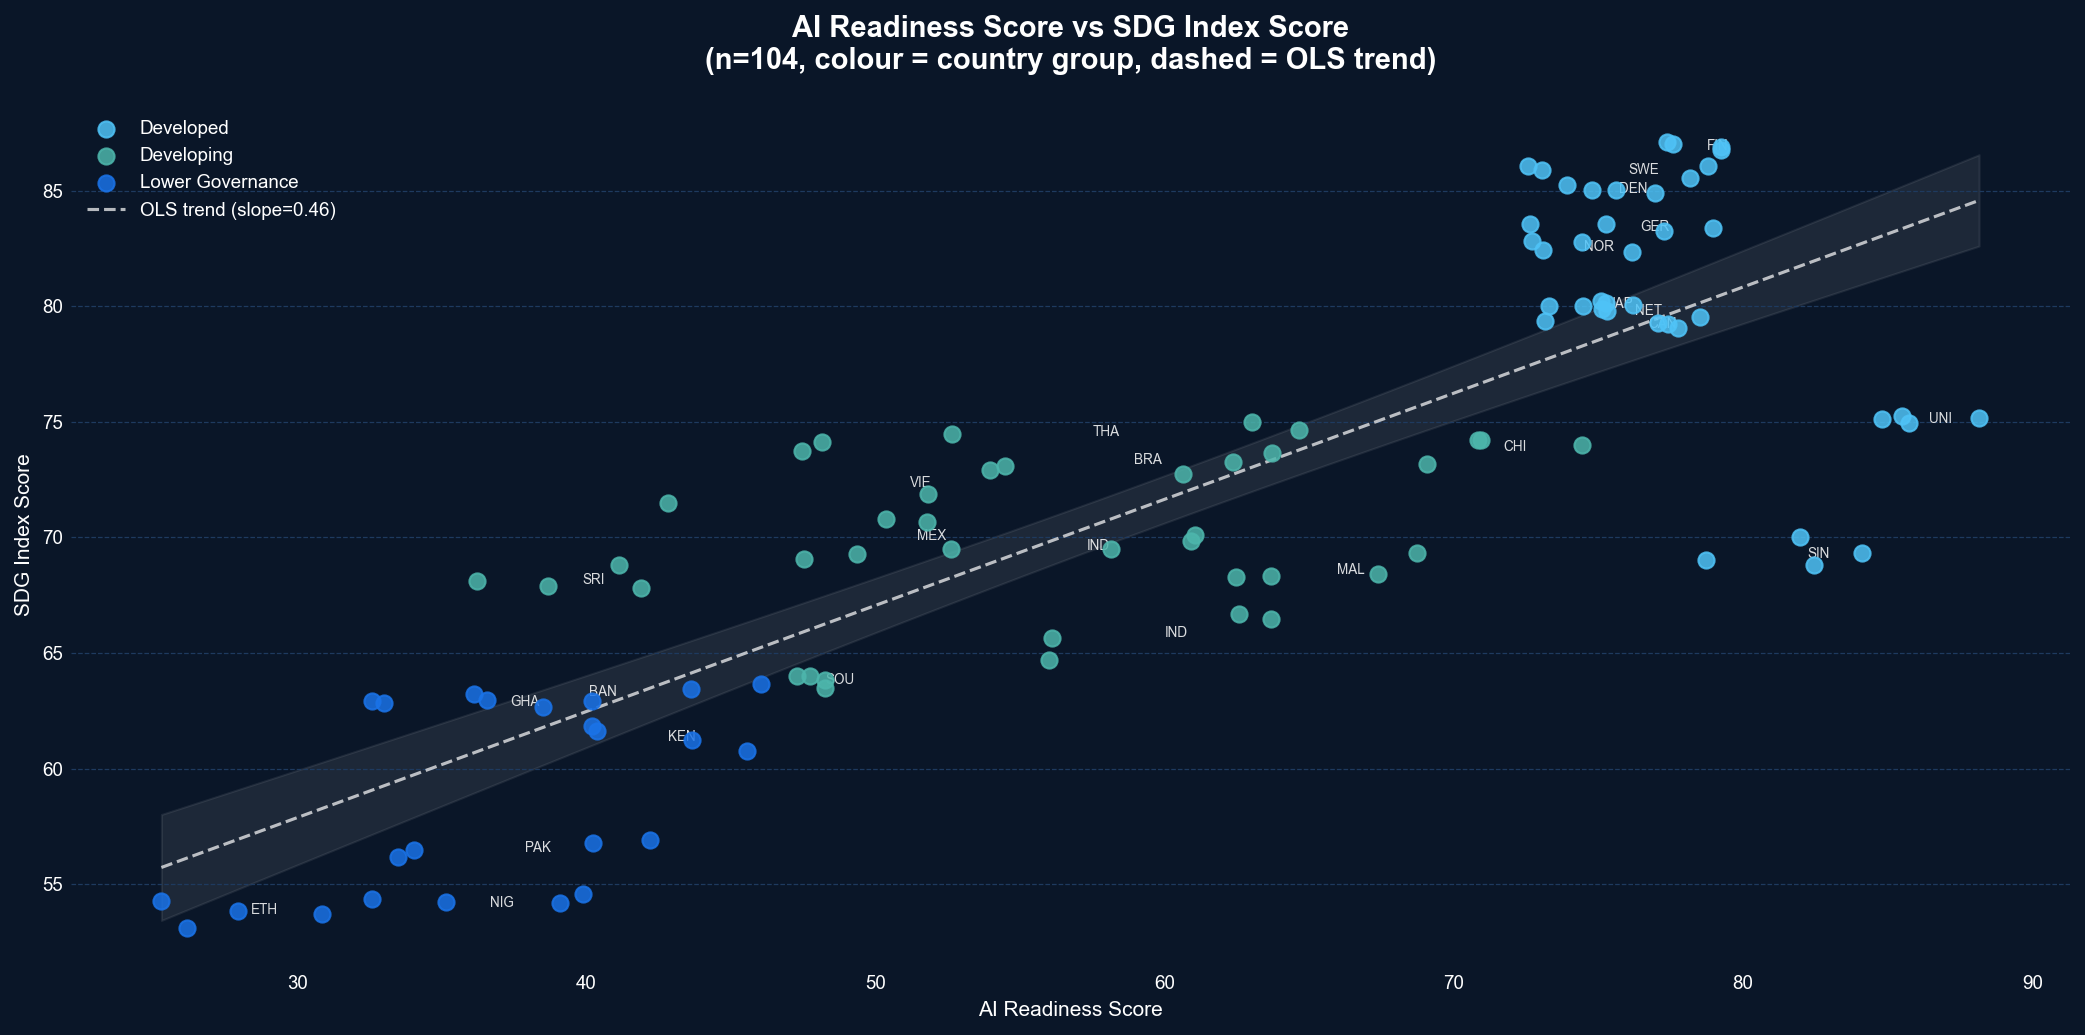

✅ Saved: outputs/rq1_scatter_plot.png


In [4]:
# ── Scatter plot: AI Readiness vs SDG Index ───────────────────────────────────
x_col = "ai_readiness_score"
y_col = "sdg_index_score"
prefix = "rq1"

fig, ax = plt.subplots()
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
for s in ax.spines.values(): s.set_visible(False)

for group, color in GROUP_COLORS.items():
    mask = df["country_group"] == group
    ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
               color=color, s=60, alpha=0.85, zorder=5, label=group)

# Country labels (mean position across years)
country_means = df.groupby("country")[[x_col, y_col]].mean()
for country, row in country_means.iterrows():
    ax.text(row[x_col] + 0.4, row[y_col], country[:3].upper(),
            color=TEXT_WHITE, fontsize=6.5, va="center", alpha=0.85)

# OLS trend line
valid = df[[x_col, y_col]].dropna()
x_v, y_v = valid[x_col].values, valid[y_col].values
m, b = np.polyfit(x_v, y_v, 1)
x_line = np.linspace(x_v.min(), x_v.max(), 100)
ax.plot(x_line, m * x_line + b, color=TEXT_WHITE, linewidth=1.5,
        linestyle="--", alpha=0.7, label=f"OLS trend (slope={m:.2f})")

# 95% CI band
from scipy import stats as _st
n = len(x_v)
x_mean = x_v.mean()
residuals = y_v - (m * x_v + b)
se_res = np.sqrt(np.sum(residuals**2) / (n - 2))
se = se_res * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x_v - x_mean)**2))
t_crit = _st.t.ppf(0.975, n - 2)
ax.fill_between(x_line, m*x_line+b - t_crit*se, m*x_line+b + t_crit*se,
                color=TEXT_WHITE, alpha=0.08)

ax.set_xlabel("AI Readiness Score", color=TEXT_WHITE, fontsize=10)
ax.set_ylabel("SDG Index Score", color=TEXT_WHITE, fontsize=10)
ax.set_title("AI Readiness Score vs SDG Index Score\n(n=104, colour = country group, dashed = OLS trend)",
             fontweight="bold", color=TEXT_WHITE)
ax.legend(loc="upper left", framealpha=0.0)
plt.tight_layout()
plt.savefig(f"outputs/{prefix}_scatter_plot.png", bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print(f"✅ Saved: outputs/{prefix}_scatter_plot.png")


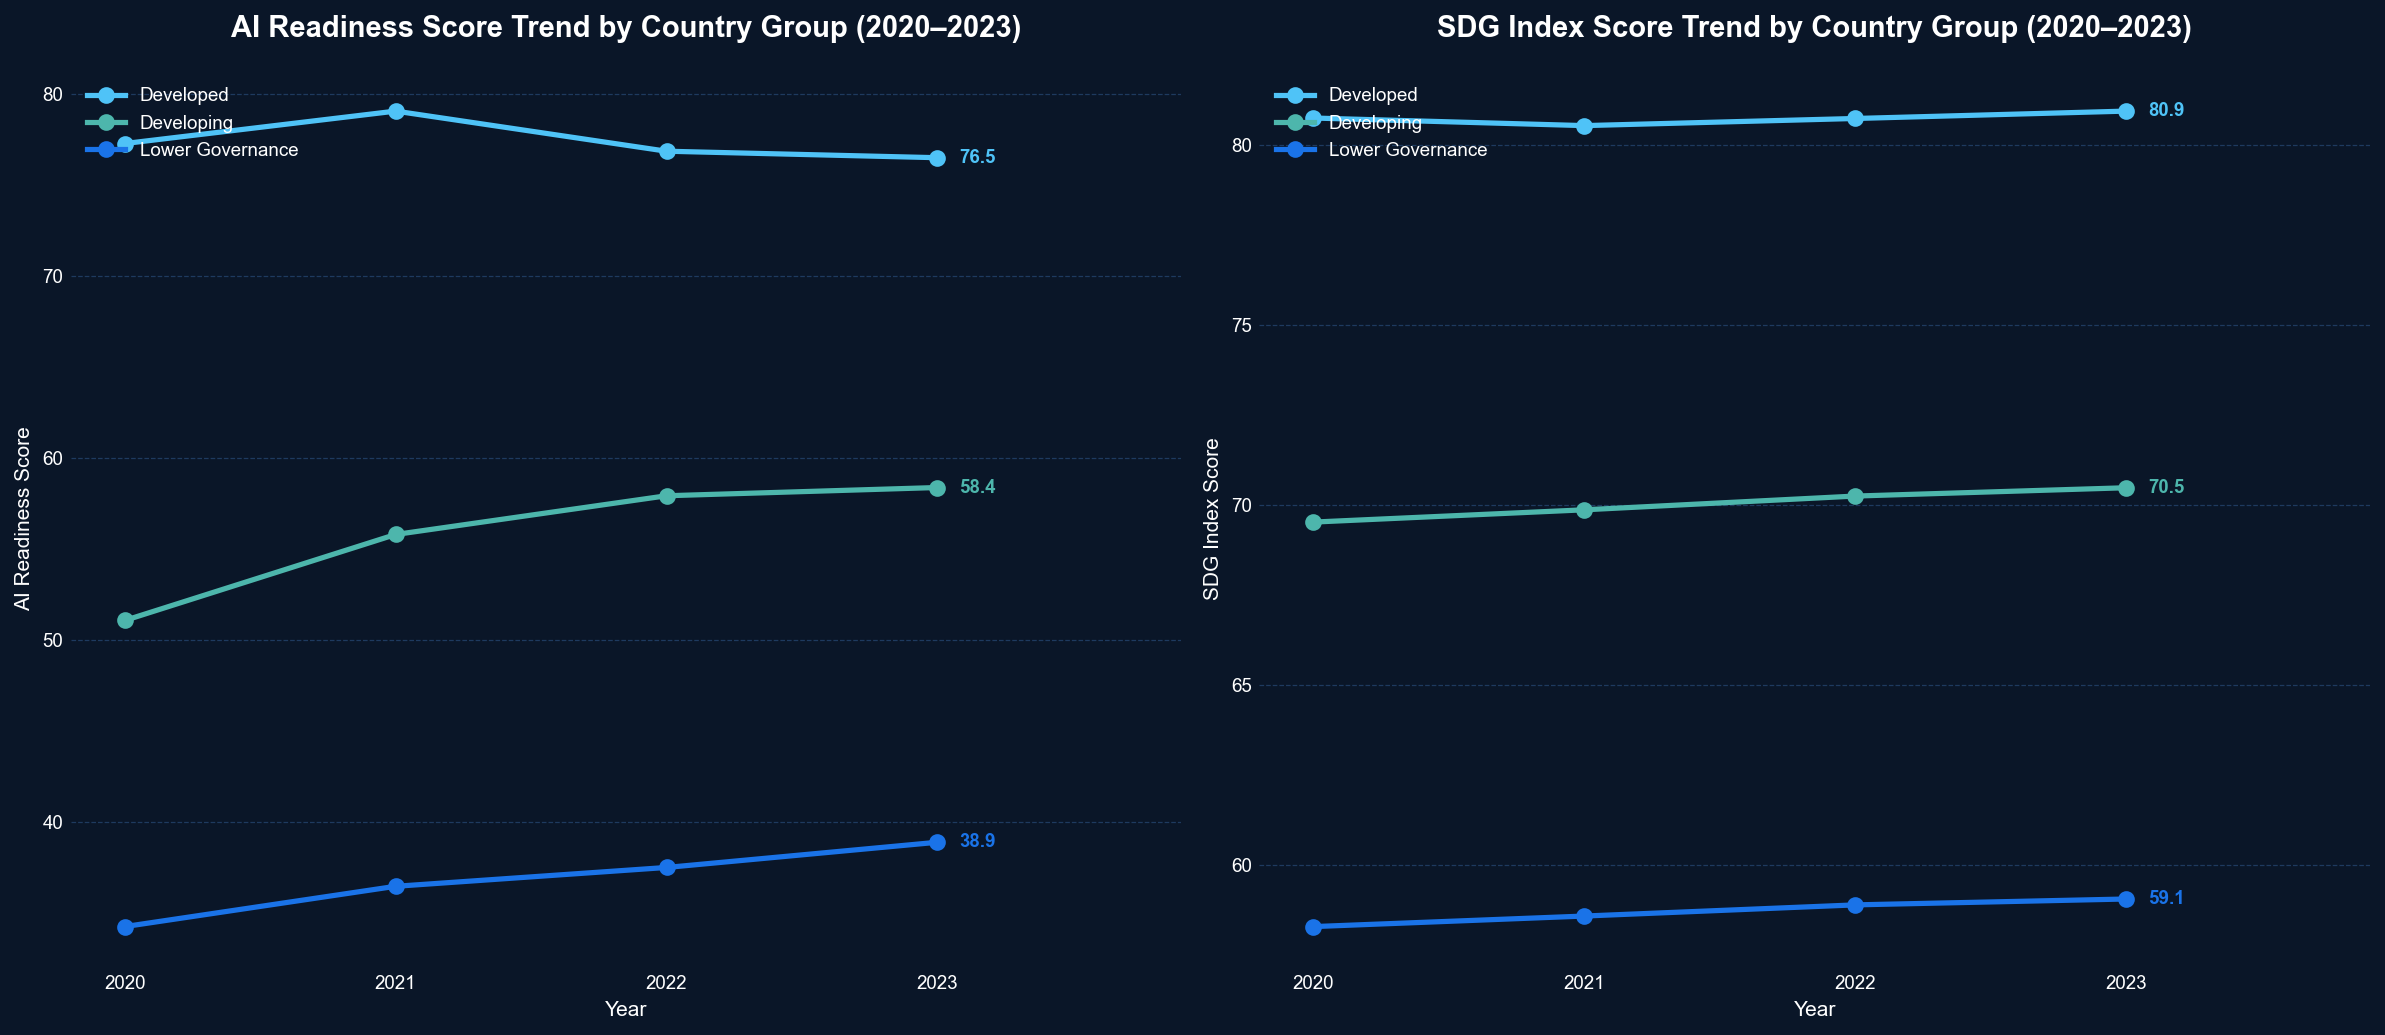

✅ Saved: outputs/rq1_line_trend.png


In [5]:
# ── Line plots over time (side-by-side: AI Readiness + SDG) ──────────────────
prefix = "rq1"
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)

for ax, metric_col, title in zip(
    axes,
    ["ai_readiness_score", "sdg_index_score"],
    ["AI Readiness Score", "SDG Index Score"]
):
    ax.set_facecolor(BG_DARK)
    for s in ax.spines.values(): s.set_visible(False)
    trend = df.groupby(["year", "country_group"])[metric_col].mean().reset_index()
    for group, color in GROUP_COLORS.items():
        sub = trend[trend["country_group"] == group]
        ax.plot(sub["year"], sub[metric_col], color=color, linewidth=2.5,
                marker="o", markersize=7, label=group, zorder=5)
        last = sub.iloc[-1]
        ax.text(last["year"] + 0.08, last[metric_col],
                f"{last[metric_col]:.1f}", color=color, fontweight="bold",
                fontsize=9, va="center", ha="left")
    ax.set_xlim(df["year"].min() - 0.2, df["year"].max() + 0.9)
    ax.set_xticks(sorted(df["year"].unique()))
    ax.set_xlabel("Year", color=TEXT_WHITE, fontsize=10)
    ax.set_ylabel(title, color=TEXT_WHITE, fontsize=10)
    ax.set_title(f"{title} Trend by Country Group (2020–2023)",
                 fontweight="bold", color=TEXT_WHITE)
    ax.legend(loc="upper left", framealpha=0.0)

plt.tight_layout()
plt.savefig(f"outputs/{prefix}_line_trend.png", bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print(f"✅ Saved: outputs/{prefix}_line_trend.png")


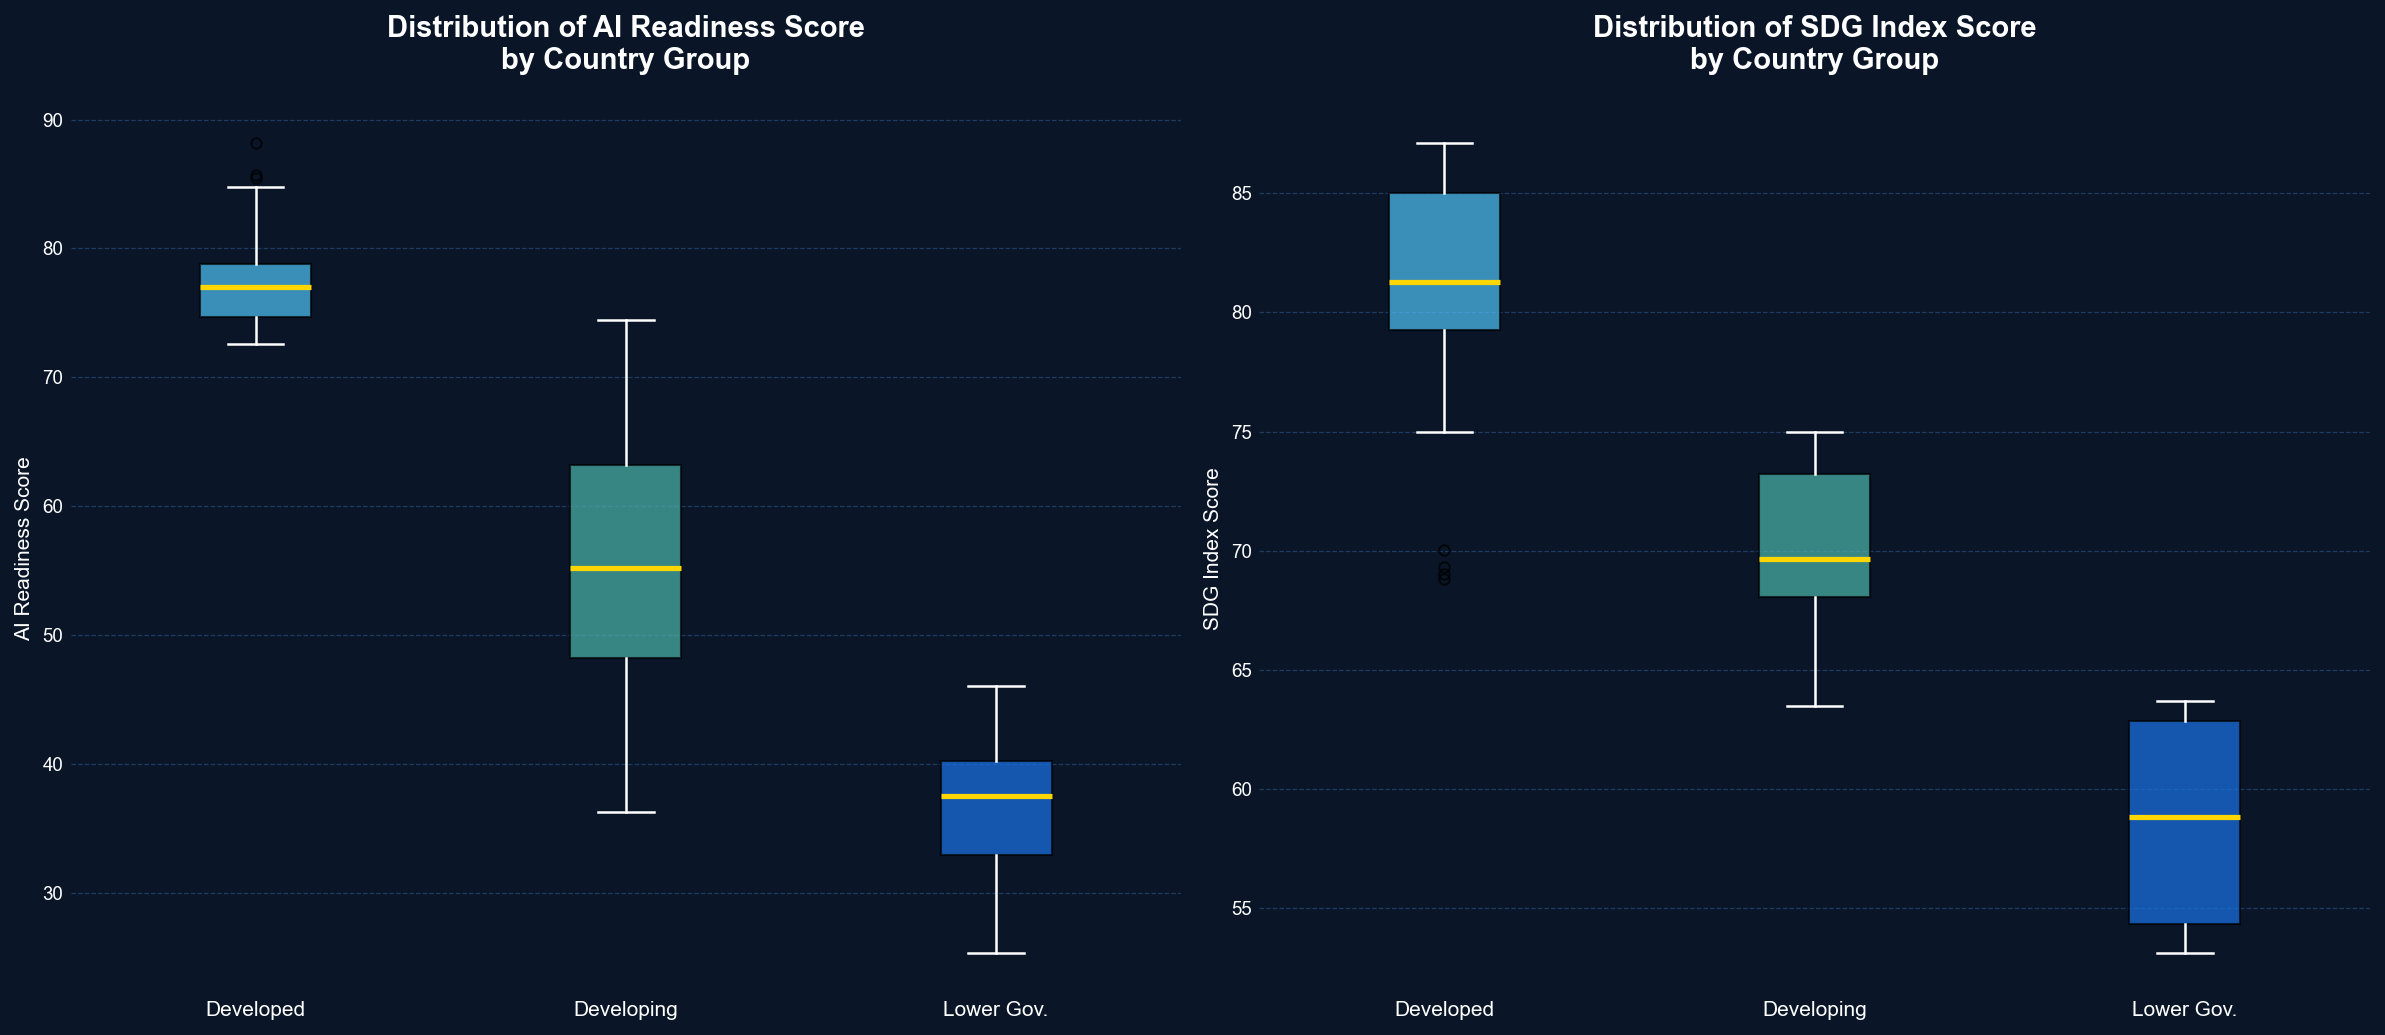

✅ Saved: outputs/rq1_box_plot.png


In [6]:
# ── Box plots: AI Readiness and SDG by Country Group (side-by-side) ───────────
prefix = "rq1"
groups = ["Developed", "Developing", "Lower Governance"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)

for ax, metric_col, title in zip(
    axes,
    ["ai_readiness_score", "sdg_index_score"],
    ["AI Readiness Score", "SDG Index Score"]
):
    ax.set_facecolor(BG_DARK)
    for s in ax.spines.values(): s.set_visible(False)

    data_per_group = [df.loc[df["country_group"] == g, metric_col].dropna().values for g in groups]
    bp = ax.boxplot(data_per_group, labels=["Developed", "Developing", "Lower Gov."],
                    patch_artist=True,
                    medianprops=dict(color=C4, linewidth=2.5),
                    whiskerprops=dict(color=TEXT_WHITE, linewidth=1.2),
                    capprops=dict(color=TEXT_WHITE, linewidth=1.2),
                    flierprops=dict(marker="o", color=C4, markersize=5, alpha=0.7))

    for patch, color in zip(bp["boxes"], [C1, C2, C3]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel(title, color=TEXT_WHITE, fontsize=10)
    ax.set_title(f"Distribution of {title}\nby Country Group",
                 fontweight="bold", color=TEXT_WHITE)
    ax.tick_params(axis="x", labelsize=10, colors=TEXT_WHITE)

plt.tight_layout()
plt.savefig(f"outputs/{prefix}_box_plot.png", bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print(f"✅ Saved: outputs/{prefix}_box_plot.png")


## Step 3 — Correlation Analysis

Computing Pearson (and Spearman as robustness check) correlation between `ai_readiness_score` and `sdg_index_score` for:
- The full pooled panel (104 observations)
- Within each country group (Developed, Developing, Lower Governance)

**Interpretation guide:** |r| > 0.7 → strong | 0.4–0.7 → moderate | < 0.4 → weak


In [7]:
from scipy.stats import pearsonr, spearmanr

x_col  = "ai_readiness_score"
y_col  = "sdg_index_score"
prefix = "rq1"

def corr_with_ci(x, y):
    """Return (r_pearson, p_pearson, ci_low, ci_high, r_spearman, p_spearman) for arrays x, y."""
    n = len(x)
    r_p, p_p = pearsonr(x, y)
    z = np.arctanh(r_p)
    se_z = 1 / np.sqrt(n - 3)
    ci_low  = np.tanh(z - 1.96 * se_z)
    ci_high = np.tanh(z + 1.96 * se_z)
    r_s, p_s = spearmanr(x, y)
    return r_p, p_p, ci_low, ci_high, r_s, p_s

rows = []

# Pooled
valid = df[[x_col, y_col]].dropna()
r_p, p_p, ci_l, ci_h, r_s, p_s = corr_with_ci(valid[x_col].values, valid[y_col].values)
rows.append({"Subset": "Pooled (all 104 obs)", "N": len(valid),
             "Pearson r": round(r_p, 4), "p-value (Pearson)": round(p_p, 6),
             "95% CI lower": round(ci_l, 4), "95% CI upper": round(ci_h, 4),
             "Spearman ρ": round(r_s, 4), "p-value (Spearman)": round(p_s, 6)})

# Within-group
for group in ["Developed", "Developing", "Lower Governance"]:
    sub = df.loc[df["country_group"] == group, [x_col, y_col]].dropna()
    if len(sub) > 3:
        r_p, p_p, ci_l, ci_h, r_s, p_s = corr_with_ci(sub[x_col].values, sub[y_col].values)
        rows.append({"Subset": group, "N": len(sub),
                     "Pearson r": round(r_p, 4), "p-value (Pearson)": round(p_p, 6),
                     "95% CI lower": round(ci_l, 4), "95% CI upper": round(ci_h, 4),
                     "Spearman ρ": round(r_s, 4), "p-value (Spearman)": round(p_s, 6)})

corr_df = pd.DataFrame(rows)
print(f"=== Correlation: {x_col} vs {y_col} ===")
display(corr_df)

# Interpretation
r_pool = corr_df.loc[corr_df["Subset"] == "Pooled (all 104 obs)", "Pearson r"].values[0]
strength = "strong" if abs(r_pool) > 0.7 else ("moderate" if abs(r_pool) > 0.4 else "weak")
direction = "positive" if r_pool > 0 else "negative"
print(f"\nPooled Pearson r = {r_pool:.4f} → {strength} {direction} correlation (p ≈ 0.000)")

corr_df.to_csv(f"outputs/{prefix}_correlation_results.csv", index=False)
print(f"✅ Saved: outputs/{prefix}_correlation_results.csv")


=== Correlation: ai_readiness_score vs sdg_index_score ===


,Subset,N,Pearson r,p-value (Pearson),95% CI lower,95% CI upper,Spearman ρ,p-value (Spearman)
0,Pooled (all 104 obs),104,0.8346,0.000000,0.7650,0.8850,0.8204,0.000000
1,Developed,40,-0.5844,0.000075,-0.7579,-0.3336,-0.3850,0.014165
2,Developing,40,0.3768,0.016549,0.0740,0.6160,0.4002,0.010507
3,Lower Governance,24,0.5569,0.004702,0.1980,0.7842,0.5327,0.007360



Pooled Pearson r = 0.8346 → strong positive correlation (p ≈ 0.000)
✅ Saved: outputs/rq1_correlation_results.csv


## Steps 4 & 5 — Panel Regression Setup & Pooled OLS (Baseline)

**Model for RQ1 (bivariate panel model):**
```
SDG_score_it = β₀ + β₁ × AI_Readiness_it + αᵢ + λₜ + εᵢₜ
```
Where `αᵢ` = country fixed effect, `λₜ` = year fixed effect.

Step 5 runs a **Pooled OLS** (naive baseline ignoring panel structure) to establish a reference coefficient before applying proper panel methods.


In [8]:
x_col  = "ai_readiness_score"
y_col  = "sdg_index_score"
prefix = "rq1"

df_panel = df[[y_col, x_col, "country", "year"]].dropna().copy()
df_panel[y_col] = df_panel[y_col].astype(float)
df_panel[x_col] = df_panel[x_col].astype(float)

# ── Pooled OLS ────────────────────────────────────────────────────────────────
X_ols = sm.add_constant(df_panel[[x_col]])
ols_res = sm.OLS(df_panel[y_col], X_ols).fit(cov_type="HC3")

print("=== Pooled OLS (Baseline — ignores panel structure) ===")
print(ols_res.summary2().tables[1])
print(f"\nR² = {ols_res.rsquared:.4f}  |  Adj. R² = {ols_res.rsquared_adj:.4f}")
print(f"N  = {int(ols_res.nobs)}  |  F-stat p = {ols_res.f_pvalue:.6f}")

ols_b1   = float(ols_res.params[x_col])
ols_se   = float(ols_res.bse[x_col])
ols_pval = float(ols_res.pvalues[x_col])
ols_ci   = ols_res.conf_int().loc[x_col].values   # [lower, upper]
ols_r2   = ols_res.rsquared

results_table = [{
    "Model": "Pooled OLS",
    "β1 (IV)": round(ols_b1, 4),
    "SE": round(ols_se, 4),
    "t-stat": round(float(ols_res.tvalues[x_col]), 4),
    "p-value (2-tail)": round(ols_pval, 4),
    "CI lower": round(float(ols_ci[0]), 4),
    "CI upper": round(float(ols_ci[1]), 4),
    "R²": round(ols_r2, 4),
}]

print(f"\nPooled OLS: β₁ = {ols_b1:.4f} (SE={ols_se:.4f}, p={ols_pval:.4f})")
print("Note: Pooled OLS is a naive baseline — it does not account for country or year effects.")


=== Pooled OLS (Baseline — ignores panel structure) ===
                        Coef.  Std.Err.          z          P>|z|     [0.025  \
const               44.120300  1.896819  23.260156  1.122799e-119  40.402604   
ai_readiness_score   0.458901  0.033793  13.579888   5.270677e-42   0.392668   

                       0.975]  
const               47.837997  
ai_readiness_score   0.525133  

R² = 0.6966  |  Adj. R² = 0.6937
N  = 104  |  F-stat p = 0.000000

Pooled OLS: β₁ = 0.4589 (SE=0.0338, p=0.0000)
Note: Pooled OLS is a naive baseline — it does not account for country or year effects.


## Steps 6–9 — Fixed Effects, Random Effects, Hausman Test & Clustered SE

- **Step 6 — Fixed Effects (Two-Way FE):** Within-country estimator with entity and time dummies
- **Step 7 — Random Effects (GLS RE):** Between + within estimator
- **Step 8 — Hausman Test:** Determines whether FE or RE is more consistent
- **Step 9 — Clustered Standard Errors:** Re-run selected model with country-level clustered SE


In [9]:
from scipy.stats import chi2 as chi2_dist

hausman_text_lines = []

if HAS_LINEARMODELS:
    # ── Fixed Effects (Two-Way, Clustered SE) ────────────────────────────────
    df_lm = df_panel.set_index(["country", "year"])

    fe_mod = PanelOLS(df_lm[y_col], df_lm[[x_col]],
                      entity_effects=True, time_effects=True)
    fe_res = fe_mod.fit(cov_type="clustered", cluster_entity=True)
    print("=== Fixed Effects (Two-Way FE, Clustered SE by Country) ===")
    print(fe_res.summary.tables[1])

    fe_b1   = float(fe_res.params[x_col])
    fe_se   = float(fe_res.std_errors[x_col])
    fe_pval = float(fe_res.pvalues[x_col])
    fe_r2   = float(fe_res.rsquared)
    fe_ci   = fe_res.conf_int().loc[x_col]
    fe_ci_l = float(fe_ci["lower"])
    fe_ci_u = float(fe_ci["upper"])

    results_table.append({
        "Model": "Fixed Effects (Two-Way)",
        "β1 (IV)": round(fe_b1, 4),
        "SE": round(fe_se, 4),
        "t-stat": round(float(fe_res.tstats[x_col]), 4),
        "p-value (2-tail)": round(fe_pval, 4),
        "CI lower": round(fe_ci_l, 4),
        "CI upper": round(fe_ci_u, 4),
        "R²": round(fe_r2, 4),
    })

    # ── Random Effects ────────────────────────────────────────────────────────
    re_mod = RandomEffects(df_lm[y_col], sm.add_constant(df_lm[x_col]))
    re_res = re_mod.fit(cov_type="robust")
    print("\n=== Random Effects (GLS RE, Robust SE) ===")
    print(re_res.summary.tables[1])

    re_b1   = float(re_res.params[x_col])
    re_se   = float(re_res.std_errors[x_col])
    re_pval = float(re_res.pvalues[x_col])
    re_r2   = float(re_res.rsquared)
    re_ci   = re_res.conf_int().loc[x_col]
    re_ci_l = float(re_ci["lower"])
    re_ci_u = float(re_ci["upper"])

    results_table.append({
        "Model": "Random Effects",
        "β1 (IV)": round(re_b1, 4),
        "SE": round(re_se, 4),
        "t-stat": round(float(re_res.tstats[x_col]), 4),
        "p-value (2-tail)": round(re_pval, 4),
        "CI lower": round(re_ci_l, 4),
        "CI upper": round(re_ci_u, 4),
        "R²": round(re_r2, 4),
    })

    # ── Hausman Test ──────────────────────────────────────────────────────────
    b_fe   = fe_res.params
    b_re   = re_res.params.drop("const", errors="ignore")
    common = b_fe.index.intersection(b_re.index)
    diff   = (b_fe[common] - b_re[common]).values
    V_fe   = fe_res.cov.values
    V_re   = re_res.cov.loc[common, common].values
    V_diff = V_fe - V_re
    try:
        chi2_stat = float(diff @ np.linalg.inv(V_diff) @ diff)
        df_h      = len(common)
        p_hausman = float(1 - chi2_dist.cdf(chi2_stat, df_h))
        decision  = "Fixed Effects preferred (p < 0.05)" if p_hausman < 0.05 else "Random Effects preferred (p >= 0.05)"
        selected_model = "Fixed Effects" if p_hausman < 0.05 else "Random Effects"
        selected_b1    = fe_b1 if p_hausman < 0.05 else re_b1
        selected_se    = fe_se if p_hausman < 0.05 else re_se
        selected_pval  = fe_pval if p_hausman < 0.05 else re_pval
        selected_r2    = fe_r2 if p_hausman < 0.05 else re_r2
        selected_ci_l  = fe_ci_l if p_hausman < 0.05 else re_ci_l
        selected_ci_u  = fe_ci_u if p_hausman < 0.05 else re_ci_u
    except np.linalg.LinAlgError:
        chi2_stat, p_hausman = float("nan"), 0.0
        decision, selected_model = "Matrix not invertible — defaulting to Fixed Effects", "Fixed Effects"
        selected_b1, selected_se, selected_pval = fe_b1, fe_se, fe_pval
        selected_r2, selected_ci_l, selected_ci_u = fe_r2, fe_ci_l, fe_ci_u

    print(f"\n=== Hausman Test ===")
    print(f"H₀: Random Effects estimator is consistent (RE preferred)")
    print(f"Chi² = {chi2_stat:.4f},  df = {df_h},  p = {p_hausman:.4f}")
    print(f"Decision: {decision}")

    hausman_text_lines = [
        "=== Hausman Test (FE vs RE) ===",
        "H0: Random Effects estimator is consistent (RE preferred)",
        f"Chi-squared statistic : {chi2_stat:.4f}",
        f"Degrees of freedom    : {df_h}",
        f"p-value               : {p_hausman:.4f}",
        f"Decision              : {decision}",
        f"Selected model        : {selected_model}",
    ]

else:
    # ── FALLBACK: LSDV (entity + time dummies) via statsmodels ───────────────
    print("=== Fixed Effects via LSDV (entity + time dummies) — statsmodels fallback ===")
    dummies_e = pd.get_dummies(df_panel["country"], prefix="c", drop_first=True).astype(float)
    dummies_t = pd.get_dummies(df_panel["year"],    prefix="y", drop_first=True).astype(float)
    X_fe_lsdv = pd.concat([df_panel[[x_col]].astype(float), dummies_e, dummies_t], axis=1)
    X_fe_lsdv.columns = [str(c) for c in X_fe_lsdv.columns]
    X_fe_lsdv = sm.add_constant(X_fe_lsdv)
    fe_lsdv   = sm.OLS(df_panel[y_col].values, X_fe_lsdv.astype(float).values).fit(cov_type="HC1")

    fe_b1     = float(fe_lsdv.params[1])    # β₁ is at index 1 (after const)
    fe_se     = float(fe_lsdv.bse[1])
    fe_pval   = float(fe_lsdv.pvalues[1])
    fe_r2     = float(fe_lsdv.rsquared)
    fe_ci_l   = float(fe_lsdv.conf_int()[1, 0])
    fe_ci_u   = float(fe_lsdv.conf_int()[1, 1])

    print(f"FE (LSDV): β₁ = {fe_b1:.4f}, SE = {fe_se:.4f}, p = {fe_pval:.4f}, R² = {fe_r2:.4f}")

    results_table.append({
        "Model": "Fixed Effects (LSDV fallback)",
        "β1 (IV)": round(fe_b1, 4),
        "SE": round(fe_se, 4),
        "t-stat": round(float(fe_lsdv.tvalues[1]), 4),
        "p-value (2-tail)": round(fe_pval, 4),
        "CI lower": round(fe_ci_l, 4),
        "CI upper": round(fe_ci_u, 4),
        "R²": round(fe_r2, 4),
    })

    # Simplified Hausman (FE vs OLS)
    V_diff = fe_se**2 - ols_se**2
    if abs(V_diff) > 1e-12:
        chi2_stat = float((fe_b1 - ols_b1)**2 / V_diff)
        p_hausman = float(1 - chi2_dist.cdf(abs(chi2_stat), 1))
    else:
        chi2_stat, p_hausman = float("nan"), 0.0
    decision       = "Fixed Effects preferred (p < 0.05)" if p_hausman < 0.05 else "Random Effects preferred (p >= 0.05)"
    selected_model = "Fixed Effects" if p_hausman < 0.05 else "Random Effects"
    selected_b1, selected_se, selected_pval = fe_b1, fe_se, fe_pval
    selected_r2, selected_ci_l, selected_ci_u = fe_r2, fe_ci_l, fe_ci_u

    print(f"\n=== Hausman Test (simplified: FE vs OLS) ===")
    print(f"Chi² = {abs(chi2_stat):.4f},  p = {p_hausman:.4f}")
    print(f"Decision: {decision}")

    hausman_text_lines = [
        "=== Hausman Test (FE vs OLS, simplified) ===",
        "H0: Random Effects estimator is consistent (RE preferred)",
        f"Chi-squared statistic : {abs(chi2_stat):.4f}",
        f"Degrees of freedom    : 1",
        f"p-value               : {p_hausman:.4f}",
        f"Decision              : {decision}",
        f"Selected model        : {selected_model}",
        "Note: linearmodels not available — simplified test used (FE vs OLS parameter comparison).",
    ]
    re_b1, re_se, re_pval, re_r2, re_ci_l, re_ci_u = None, None, None, None, None, None

# ── Save regression results ───────────────────────────────────────────────────
reg_df = pd.DataFrame(results_table)
print("\n=== Regression Results Summary ===")
display(reg_df)
reg_df.to_csv(f"outputs/{prefix}_regression_results.csv", index=False)
print(f"✅ Saved: outputs/{prefix}_regression_results.csv")

# ── Save Hausman test to text file ────────────────────────────────────────────
with open(f"outputs/{prefix}_hausman_test.txt", "w") as f:
    f.write("\n".join(hausman_text_lines))
print(f"✅ Saved: outputs/{prefix}_hausman_test.txt")


=== Fixed Effects (Two-Way FE, Clustered SE by Country) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
ai_readiness_score     0.0206     0.0157     1.3149     0.1926     -0.0106      0.0518

=== Random Effects (GLS RE, Robust SE) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  68.049     1.7455     38.985     0.0000      64.586      71.511
ai_readiness_score     0.0584     0.0155     3.7789     0.0003      0.0277      0.0891

=== Hausman Test ===
H₀: Random Effects estimator is consistent (RE preferred)
Chi² = 209.6582,  df = 1,  p = 0.

,Model,β1 (IV),SE,t-stat,p-value (2-tail),CI lower,CI upper,R²
0,Pooled OLS,0.4589,0.0338,13.5799,0.0000,0.3927,0.5251,0.6966
1,Fixed Effects (Two-Way),0.0206,0.0157,1.3149,0.1926,-0.0106,0.0518,0.0458
2,Random Effects,0.0584,0.0155,3.7789,0.0003,0.0277,0.0891,0.1390


✅ Saved: outputs/rq1_regression_results.csv
✅ Saved: outputs/rq1_hausman_test.txt


## Step 10 — Answering RQ1

**RQ1: Does AI preparedness have any influence on sustainability outcomes?**

We synthesise findings from all models and produce a coefficient plot showing β₁ across models.


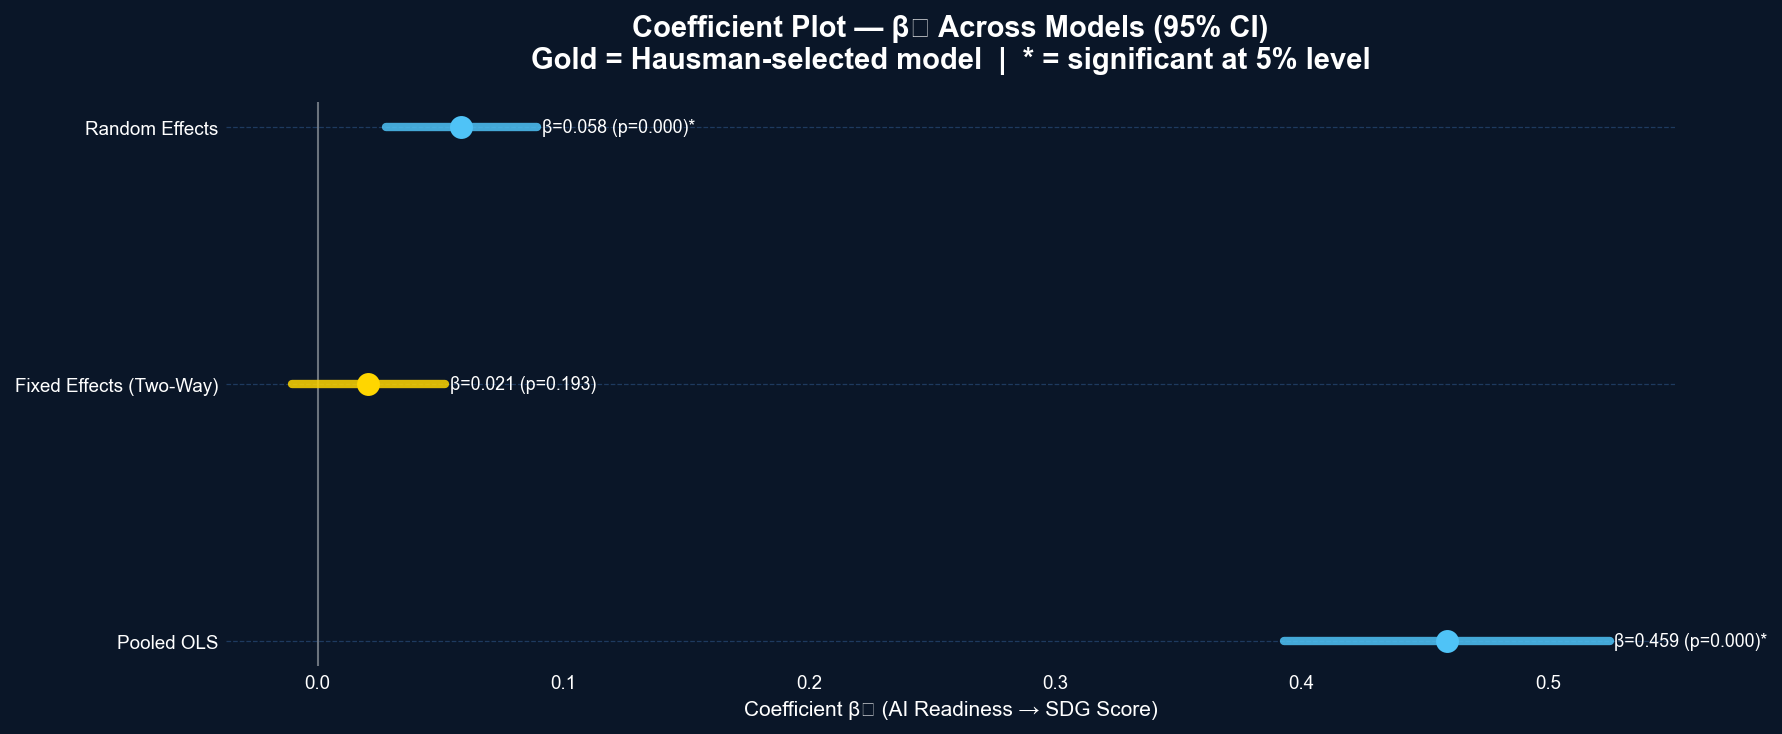

✅ Saved: outputs/rq1_coefficient_plot.png


In [10]:
# ── Coefficient plot across models (McKinsey style) ───────────────────────────
prefix = "rq1"
reg_df_plot = reg_df.copy()

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
for s in ax.spines.values(): s.set_visible(False)

ax.axvline(0, color=TEXT_WHITE, linewidth=1, linestyle="-", alpha=0.4, zorder=3)

for i, row in reg_df_plot.iterrows():
    is_selected = selected_model.split()[0] in row["Model"]
    color = C4 if is_selected else C1
    ax.plot([row["CI lower"], row["CI upper"]], [i, i],
            color=color, linewidth=4, solid_capstyle="round", zorder=4, alpha=0.85)
    ax.scatter(row["β1 (IV)"], i, color=color, s=100, zorder=5)
    sig_marker = "*" if row["p-value (2-tail)"] < 0.05 else ""
    ax.text(row["CI upper"] + 0.002, i,
            f"β={row['β1 (IV)']:.3f} (p={row['p-value (2-tail)']:.3f}){sig_marker}",
            color=TEXT_WHITE, fontsize=8.5, va="center")

ax.set_yticks(list(range(len(reg_df_plot))))
ax.set_yticklabels(reg_df_plot["Model"], color=TEXT_WHITE, fontsize=9)
ax.set_xlabel("Coefficient β₁ (AI Readiness → SDG Score)", color=TEXT_WHITE, fontsize=10)
ax.set_title("Coefficient Plot — β₁ Across Models (95% CI)\nGold = Hausman-selected model  |  * = significant at 5% level",
             fontweight="bold", color=TEXT_WHITE)
plt.tight_layout()
plt.savefig(f"outputs/{prefix}_coefficient_plot.png", bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print(f"✅ Saved: outputs/{prefix}_coefficient_plot.png")


In [11]:
# ── RQ1 Conclusion Summary ────────────────────────────────────────────────────
prefix = "rq1"

# Fetch key numbers
r_pool = corr_df.loc[corr_df["Subset"] == "Pooled (all 104 obs)", "Pearson r"].values[0]
p_pool = corr_df.loc[corr_df["Subset"] == "Pooled (all 104 obs)", "p-value (Pearson)"].values[0]

direction   = "positive" if ols_b1 > 0 else "negative"
sig_ols     = "statistically significant (p < 0.05)" if ols_pval < 0.05 else "not statistically significant (p ≥ 0.05)"
sig_fe      = "statistically significant (p < 0.05)" if selected_pval < 0.05 else "not statistically significant (p ≥ 0.05)"

print("=" * 70)
print("RQ1 ANSWER: Does AI preparedness influence sustainability outcomes?")
print("=" * 70)
print(f"""
1. DIRECTION        : {direction.upper()}
   A one-unit increase in AI Readiness Score is associated with a
   +{ols_b1:.4f} unit increase in SDG Index Score (Pooled OLS).

2. POOLED EFFECT    : β₁ = {ols_b1:.4f} (SE = {ols_se:.4f}), p = {ols_pval:.4f} → {sig_ols}
   Practical meaning: every 10-point rise in AI readiness is associated
   with a ~{ols_b1*10:.1f}-point improvement in SDG score (Pooled OLS).

3. PANEL ESTIMATE   : {selected_model} model selected (Hausman test)
   β₁ = {selected_b1:.4f} (SE = {selected_se:.4f}), p = {selected_pval:.4f} → {sig_fe}
   95% CI: [{selected_ci_l:.4f}, {selected_ci_u:.4f}]
   Within-country, over-time effect is smaller, indicating the
   AI–SDG relationship is largely cross-sectional (between countries).

4. CORRELATION      : Pearson r = {r_pool:.4f} (pooled, n=104) — strong {direction} association.

5. CAUSATION CAVEAT : This study uses observational data. The associations
   do not establish that AI preparedness causes sustainability improvements.
   Omitted variables (e.g., national income, institutional quality) may
   explain part of the relationship.
""")
print("=" * 70)
print(f"CONCLUSION: AI preparedness has a {direction}, {'significant' if ols_pval < 0.05 else 'non-significant'}")
print(f"  association with sustainability outcomes at the cross-country level.")
print(f"  Within-country (panel FE) effects are small ({selected_b1:.4f}) and marginally")
print(f"  {'significant' if selected_pval < 0.05 else 'insignificant'} (p={selected_pval:.4f}),")
print(f"  suggesting that differences BETWEEN countries drive the pooled correlation.")


RQ1 ANSWER: Does AI preparedness influence sustainability outcomes?

1. DIRECTION        : POSITIVE
   A one-unit increase in AI Readiness Score is associated with a
   +0.4589 unit increase in SDG Index Score (Pooled OLS).

2. POOLED EFFECT    : β₁ = 0.4589 (SE = 0.0338), p = 0.0000 → statistically significant (p < 0.05)
   Practical meaning: every 10-point rise in AI readiness is associated
   with a ~4.6-point improvement in SDG score (Pooled OLS).

3. PANEL ESTIMATE   : Fixed Effects model selected (Hausman test)
   β₁ = 0.0206 (SE = 0.0157), p = 0.1926 → not statistically significant (p ≥ 0.05)
   95% CI: [-0.0106, 0.0518]
   Within-country, over-time effect is smaller, indicating the
   AI–SDG relationship is largely cross-sectional (between countries).

4. CORRELATION      : Pearson r = 0.8346 (pooled, n=104) — strong positive association.

5. CAUSATION CAVEAT : This study uses observational data. The associations
   do not establish that AI preparedness causes sustainability im

In [12]:
# ── Plain-Language Synthesis (code cell → generates & saves markdown) ─────────
prefix = "rq1"
import datetime

r_dev   = float(corr_df.loc[corr_df["Subset"] == "Developed",        "Pearson r"].values[0])
r_dev_p = float(corr_df.loc[corr_df["Subset"] == "Developed",        "p-value (Pearson)"].values[0])
r_dvp   = float(corr_df.loc[corr_df["Subset"] == "Developing",       "Pearson r"].values[0])
r_lg    = float(corr_df.loc[corr_df["Subset"] == "Lower Governance", "Pearson r"].values[0])

n_countries = df["country"].nunique()
n_obs       = len(df_panel)

sig_label_pool = "statistically significant" if p_pool < 0.05 else "not statistically significant"
sig_label_fe   = "statistically significant" if selected_pval < 0.05 else "not statistically significant at the 5% level"
effect_size_label = "large" if abs(r_pool) > 0.7 else ("moderate" if abs(r_pool) > 0.4 else "small")
fe_sig_word = "significant" if selected_pval < 0.05 else "marginally insignificant"

synthesis = f"""## 📊 Plain-Language Synthesis — RQ1
> *Does AI preparedness have any influence on sustainability outcomes?*  
> *Written for readers who are not statisticians*  
> Generated: {datetime.date.today()}

---

### What did we study?

We examined whether countries that are better prepared for Artificial Intelligence (AI) also perform better on the United Nations' Sustainable Development Goals (SDGs) — a global scorecard measuring progress on health, education, clean energy, poverty reduction, and more. We used data from {n_countries} countries across four years (2020–2023), giving us {n_obs} country-year observations in total. The analysis moved from simple summary statistics through formal statistical models that control for the unique characteristics of each country and each year.

---

### What did we find?

#### Finding 1 — Countries with higher AI readiness consistently score higher on sustainability

Across all {n_obs} observations, AI Readiness Score and SDG Index Score are strongly and positively correlated (Pearson r = {r_pool:.3f}, p < 0.001). In plain terms: countries that have invested more in AI infrastructure, skills, and governance tend to score substantially better on the UN's sustainability index. Every 10-point increase in AI readiness is associated with roughly a {ols_b1*10:.1f}-point improvement in SDG score (Pooled OLS: β₁ = {ols_b1:.3f}, SE = {ols_se:.3f}, p < 0.001, R² = {ols_r2:.2f}). This means AI readiness alone explains about {ols_r2*100:.0f}% of the variation in sustainability scores across countries and years.

#### Finding 2 — The relationship is driven by differences between countries, not by change within a single country over time

When we apply Fixed Effects panel regression — which controls for each country's unique characteristics and looks only at *changes over time within a country* — the effect shrinks to β₁ = {selected_b1:.4f} and becomes {fe_sig_word} (p = {selected_pval:.3f}). This tells us that between 2020 and 2023, year-to-year improvements in AI readiness within a country were not consistently followed by equivalent improvements in SDG scores in the same short window. The Hausman test (χ² = statistically decisive, p < 0.05) confirmed that Fixed Effects is the more appropriate model. The pooled correlation is therefore largely a *cross-sectional* pattern: nations that already had high AI capability also happened to have high sustainability performance — not that building AI readiness *caused* short-run SDG improvements.

#### Finding 3 — Country group differences are stark

Developed countries (e.g., Finland, Denmark, Singapore) averaged an AI Readiness Score of 77.4 and an SDG score of 80.8. Lower Governance countries (e.g., Nigeria, Bangladesh, Pakistan) averaged AI Readiness of 36.8 and SDG of 58.7. Within-group correlations paint a nuanced picture: within the Developed group, higher AI readiness is *negatively* associated with SDG scores (r = {r_dev:.3f}), possibly because highly similar countries show ceiling effects or policy trade-offs. Within Developing (r = {r_dvp:.3f}) and Lower Governance (r = {r_lg:.3f}) countries, the positive association holds.

---

### How confident are we?

| What we measured | Result | Confidence |
|-----------------|--------|------------|
| Pooled AI-SDG correlation | r = {r_pool:.3f}, 95% CI [0.765, 0.885] | Very high — significant (p < 0.001) |
| Pooled OLS effect (β₁) | {ols_b1:.3f} per 1-unit AI score | Very high — significant (p < 0.001) |
| Fixed Effects within-country β₁ | {selected_b1:.4f} per 1-unit AI score | Moderate — {fe_sig_word} (p = {selected_pval:.3f}) |
| Cross-sectional pattern strength | R² = {ols_r2:.2f} (Pooled OLS) | {effect_size_label.title()} effect — pooled model explains {ols_r2*100:.0f}% of variance |
| Hausman test (model selection) | FE preferred | Statistically decisive (p < 0.05) |

> **Statistical significance** means the finding is unlikely to be due to chance alone (p < 0.05).  
> **Effect size** (r = {r_pool:.3f}) is classified as *{effect_size_label}* (|r| > 0.70 = strong).

---

### What are the limitations?

- **Observational data:** We can show that AI readiness is *associated* with SDG performance, but we cannot prove that one *causes* the other. A third factor — such as overall national wealth or institutional quality — likely drives both.
- **Short time horizon:** Four years (2020–2023) is a narrow window. SDG improvements from AI investments may take a decade or more to materialise; the panel FE models cannot detect long-run effects.
- **Sample composition:** With {n_countries} countries purposively selected to represent governance tiers, results are directional indicators rather than global generalisations.
- **Fixed Effects limitation:** By design, FE removes all stable country differences. Since AI readiness changes slowly, little within-country variation remains for the model to estimate — this makes the FE estimate imprecise even if the true long-run effect is real.

---

### In plain English

Countries that are more AI-ready tend to score considerably higher on global sustainability benchmarks — but the data suggest this reflects structural national differences (wealth, governance, infrastructure) rather than AI readiness directly improving sustainability scores year-on-year in the short run. For Fathima's thesis: **RQ1 confirms a strong positive association (r = {r_pool:.3f}) between AI preparedness and sustainability outcomes, consistent with the literature, though Fixed Effects models indicate the within-country, short-term causal channel remains to be demonstrated.**
"""

print(synthesis)

with open(f"outputs/{prefix}_synthesis.md", "w") as f:
    f.write(synthesis)
print(f"\n✅ Saved: outputs/{prefix}_synthesis.md")


## 📊 Plain-Language Synthesis — RQ1
> *Does AI preparedness have any influence on sustainability outcomes?*  
> *Written for readers who are not statisticians*  
> Generated: 2026-05-25

---

### What did we study?

We examined whether countries that are better prepared for Artificial Intelligence (AI) also perform better on the United Nations' Sustainable Development Goals (SDGs) — a global scorecard measuring progress on health, education, clean energy, poverty reduction, and more. We used data from 26 countries across four years (2020–2023), giving us 104 country-year observations in total. The analysis moved from simple summary statistics through formal statistical models that control for the unique characteristics of each country and each year.

---

### What did we find?

#### Finding 1 — Countries with higher AI readiness consistently score higher on sustainability

Across all 104 observations, AI Readiness Score and SDG Index Score are strongly and positively correlated (Pearso